# Konveierid (*Pipeline*), mudelite hindamine ja hüperparameetrite tuunimine


## Sisukord

* [Konveier](#konveier)
* [Ristkontroll](#ristkontroll)
* [Ülesanne 7.1](#7_1)
* [Õppimiskõverad](#õppimiskõverad)
* [Validatsioonikõverad](#validatsioonikõverad)
* [Hüperparameetrite tuunimine](#hüper)
* [Eksimismaatriks](#Eksimismaatriks)
* [ROC kõver](#roc)
* [Ülesanne 7.2](#7_2)

Põhineb S.Raschka *Python Machine Learnig* raamatu [peatükil 6](https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch06/ch06.ipynb) ([*MIT litsents*](https://github.com/rasbt/python-machine-learning-book/blob/master/LICENSE.txt)).

<a id='konveier'></a>
## Konveier (pipeline)


Nagu oleme näinud, on [sklearn](https://scikit-learn.org/stable/) põhises andmeanalüüsis tavaliselt mitu programmeerimissammu: standardiseerimine/normaliseerimine, dimensionaalsuse vähendamine, ennustava mudeli treenimine ja kasutamine. Need on osa üldisemast andmekaeve protsessist, mille tüüpilist vormi - valdkonna analüüs, andmete analüüs, andmete eeltöötlus, modelleerimine, mudelite hindamine ja mudelite juurutamine - kirjeldab [CRISP-DM](https://www.datascience-pm.com/crisp-dm-2/). Konveier ([Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)) kombineerib erinevad transfomaatorid ja ennustajad kokku ühendobjektiks, mille liideses on muu hulgas  fit() ja transform() meetodid. See lihtsutab loodud mudeli testimist ja kasutamist, kuna kõik vajalikud teisendused on kapseldatud ühte objekti.


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd



In [2]:
# Andmete laadimine, vaatame veeloomaks olekut ja ignoreerime tüüpi
zoo_df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data", 
                     header=None, index_col=0,
                     names=["animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail", "domestic", "catsize", "type" ])
zoo_class =  zoo_df.pop("aquatic")
zoo_df.pop("type")
zoo_df

,hair,feathers,eggs,milk,airborne,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
animal_name,,,,,,,,,,,,,,,
aardvark,1,0,0,1,0,1,1,1,1,0,0,4,0,0,1
antelope,1,0,0,1,0,0,1,1,1,0,0,4,1,0,1
bass,0,0,1,0,0,1,1,1,0,0,1,0,1,0,0
bear,1,0,0,1,0,1,1,1,1,0,0,4,0,0,1
boar,1,0,0,1,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wallaby,1,0,0,1,0,0,1,1,1,0,0,2,1,0,1
wasp,1,0,1,0,1,0,0,0,1,1,0,6,0,0,0
wolf,1,0,0,1,0,1,1,1,1,0,0,4,1,0,1


Tekitame konveieri, mille sammudeks on standardiseerimine, PCA ja logistiline regressioon. Konveieri tekitamisel anname me sinna kaasa listi `(nimi, komponent)` paaridest. Nimi on vabalt valitav string.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(zoo_df, 
                                                    zoo_class, 
                                                    test_size=0.2, 
                                                    random_state=1)

pipe_lr = Pipeline([('sc1', StandardScaler()),
                    ('pca', PCA(n_components=2)),
                    ('clf', LogisticRegression(random_state=1))])



Kui meie konveier `pipeline` koosneb n komponendist `p_1..., p_n`, 
siis selle `fit_transform()` meetod rakendab andmestikule `X` järjest komponentide `p1,... p_{n}` teisendusmeetodeid `fit_transform()`
(kõigepealt `fit()`, seejärel `transform()`).


Kui meie konveier `pipeline` koosneb n komponendist `p_1..., p_n`, siis selle `fit()` meetod rakendab andmestikule `X` järjest komponentide `p1,... p_{n-1}` teisendusmeetodeid `fit_transform()` (kõigepealt `fit()`, seejärel `transform()`) ja lõpuks viimase komponendi `p_n.fit(X, y)` meetodit, salvestades tulemuse.

`pipeline.fit(X, y): 
                     p_n.fit(p_{n-1}.fit_transform(
                              ...
                             p_2.fit_transform(
                             p_1.fit_transform(X))),...), y)`

In [4]:
pipe_lr.fit(X_train, y_train)
print('Täpsus: ', pipe_lr.score(X_test, y_test))

Täpsus:  0.8095238095238095


Kui meie konveier `pipeline` koosneb n komponendist `p_1..., p_n`, siis selle `predict()` meetod rakendab andmestikule `X` järjest komponentide `p1,... p_{n-1}` teisendusmeetodeid `transform()`ja lõpuks viimase komponendi `p_n.predict(X)` meetodit, salvestades tulemuse.

`pipeline.predict(X): 
                 p_n.predict(p_{n-1}.transform(
                              ...
                             p_2.transform(
                             p_1.transform(X))))`

In [5]:
y_pred = pipe_lr.predict(X_test)
sum(y_pred == y_test) / len(y_test)


0.8095238095238095

In [6]:
len(y_pred)

21

Ligipääs konveieri komponentidele toimub komponentidele antud stringitähiste abil, kasutades konveierit sõnastikuna. 

In [7]:
print("Logistilise regressiooni koefitsendid:", pipe_lr['clf'].coef_)

Logistilise regressiooni koefitsendid: [[-0.23270002  1.29966205]]


<a id='ristkontroll'></a>
## Ristkontroll (cross-validation)

$k$-kordne ristkontroll jagab andmestiku $k$ võrdseks juhuvalimiks, kus $k-1$ juhuvalimit kasutatakse treeninguks ja viimast juhuvalimit testimiseks. Seda protseduri korratakse k korda, kuni testitud on kõiki juhuvalimeid. Koguhinnang $E$ (täpsus vms) on keskmine hinnang üle $k$ hinnangu:

$$E = \frac{\sum_{i=1}^k E_i}{k} $$

Scikit-learn teegis on ristkontrolliks moodulis model_selection klassid, nagu [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold), mis võimaldavad täpsemat kontrolli iteratsiooniks üle $k$ valimi ja lihtsamat funktsiooni [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html), mis tagastab täpsusskoorid iga $k$ valimi jaoks ja võimaldab paralleeltööd mitme protsessoriga (parameeter `n_jobs`).

In [8]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold




Parameeter `cv` on korduste/juhuvalimite arv.
Parameeter `n_jobs` on lõimede/kasutatavate protsessorite arv.

In [9]:
#%%timeit # Jupyteri käsk ajakulu mõõtmiseks

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)

In [10]:
print('CV täpsused: ', scores)
print('CV keskmine täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

CV täpsused:  [1.    0.875 0.75  0.625 0.625 0.875 0.625 0.875 0.75  0.875]
CV keskmine täpsus: 0.787 +/- 0.126


Meetod `StratifiedKFold.split(X, y)` tagastab listi paaridest `(treeningandmete_indeksid, testandmete_indeksid)`.

In [11]:
kfold = StratifiedKFold(n_splits=10)
for train, test in kfold.split(X_train, y_train):
    # Kuna StratifiedKFold tagastab täisarvulised indeksid, siis kasutame iloc-i.   print("test: ", ", ".join(X_train.iloc[test].index)) 
    pipe_lr.fit(X_train.iloc[train], y_train.iloc[train])
    score = pipe_lr.score(X_train.iloc[test], y_train.iloc[test])
    print("objects:", ",".join(X_train.iloc[test].index))
    print("score:", score)



objects: gorilla,housefly,honeybee,herring,lobster,ladybird,cheetah,bass
score: 1.0
objects: opossum,puma,seahorse,dolphin,fruitbat,mink,tortoise,wolf
score: 0.875
objects: penguin,octopus,moth,seal,flamingo,ostrich,raccoon,squirrel
score: 0.75
objects: haddock,swan,crayfish,kiwi,lion,worm,lark,pheasant
score: 0.625
objects: tuna,frog,flea,boar,pitviper,toad,mole,termite
score: 0.625
objects: duck,bear,wallaby,gnat,lynx,seawasp,catfish,aardvark
score: 0.875
objects: pike,tuatara,parakeet,elephant,piranha,platypus,wasp,clam
score: 0.625
objects: carp,pussycat,stingray,crab,girl,giraffe,chicken,dove
score: 0.875
objects: dogfish,mongoose,frog,calf,rhea,seasnake,antelope,crow
score: 0.75
objects: polecat,skua,buffalo,sealion,cavy,scorpion,chub,hawk
score: 0.875


<a id='7_1'></a>
## Ülesanne 7.1


* Tekitada komponentidest [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html) (parameeter`k=3`),
[DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) koosnev konveier, rakendada seda loomaaia andmetele ja hinnata selle täpsust veeloomaks olemise ennustamisel (importida vajalikud moodulid ja klassid).


* Tekitada komponentidest [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), 
[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) (parameeter `n_components=2`),
[Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) koosnev konveier, rakendada seda loomaaia andmetele ja hinnata selle täpsust.

 
* Hinnata [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html),
[DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) konveieri täpsust 10x ristkontrolliga.


* Hinnata [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), 
[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html),
[Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)  konveieri täpsust 10x ristkontrolliga.

In [12]:
from sklearn.feature_selection import SelectKBest
from sklearn.tree import DecisionTreeClassifier
# Tekitame konveieri, mis koosneb komponentidest SelectKBest ja DecisionTreeClassifier 
pipeline1 = Pipeline([('selectkbest', SelectKBest(k=3)), 
                    ('decisiontreeclassifier', DecisionTreeClassifier())])
# Rakendame konveierit loomaaia andmetel
X_train1, X_test1, y_train1, y_test1 = train_test_split(zoo_df, 
                                                    zoo_class, 
                                                    test_size=0.2, 
                                                    random_state=1)
pipeline1.fit(X_train1, y_train1)
# Hindame konveieri täpsust veeloomaks olemise ennustamisel
print('Täpsus: ', pipeline1.score(X_test1, y_test1))

# y_pred1 = pipeline1.predict(X_test1)
# sum(y_pred1 == y_test1) / len(y_test1)

# Hinnata SelectKBest, DecisionTreeClassifier konveieri täpsust 10x ristkontrolliga (cross_val_score()-st peaks piisama)
scores1 = cross_val_score(estimator=pipeline1,
                         X=X_train1,
                         y=y_train1,
                         cv=10,
                         n_jobs=1)
print('CV täpsused: ', scores1)
print('CV keskmine täpsus: %.3f' % np.mean(scores1), "+/- %.3f" % np.std(scores1))

Täpsus:  0.8571428571428571


CV täpsused:  [1.    0.875 0.875 0.875 0.75  0.875 0.75  1.    0.875 0.875]
CV keskmine täpsus: 0.875 +/- 0.079


In [13]:
from sklearn.linear_model import Perceptron
# Tekitada komponentidest StandardScaler, PCA(parameeter `n_components=2`),Perceptron 
pipeline2 = Pipeline([('sc1', StandardScaler()), 
                    ('pca', PCA(n_components=2)),
                    ('perceptron', Perceptron())])
# Rakendame konveierit loomaaia andmetel
X_train2, X_test2, y_train2, y_test2 = train_test_split(zoo_df, 
                                                    zoo_class, 
                                                    test_size=0.2, 
                                                    random_state=1)
pipeline2.fit(X_train2, y_train2)
# Hindame konveieri täpsust 
print('Täpsus: ', pipeline2.score(X_test2, y_test2))

# Hinnata StandardScaler, PCA,Perceptron konveieri täpsust 10x ristkontrolliga (cross_val_score()-st peaks piisama)
scores2 = cross_val_score(estimator=pipeline2,
                         X=X_train2,
                         y=y_train2,
                         cv=10,
                         n_jobs=1)
print('CV täpsused: ', scores2)
print('CV keskmine täpsus: %.3f' % np.mean(scores2), "+/- %.3f" % np.std(scores2))

Täpsus:  0.8095238095238095
CV täpsused:  [1.    0.625 0.625 0.625 0.875 0.875 0.5   0.875 0.75  0.625]
CV keskmine täpsus: 0.738 +/- 0.153


<a id='õppimiskõverad'></a>
## Õppimiskõverad


Õppimiskõver näitab treening- ja testtäpsuse sõltuvust andmestiku suurusest. See võimaldab hinnata kuivõrd paraneks täpsus andmemahtu suurendades.

In [14]:
from sklearn.model_selection import learning_curve

pipe_lr = Pipeline([('scl', StandardScaler()),
                    ('clf', LogisticRegression(penalty='l2',
                                               #solver='liblinear',
                                               max_iter=100, 
                                               random_state=0))])



In [15]:


train_sizes, train_scores, test_scores =\
                learning_curve(estimator=pipe_lr,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 5),
                               scoring='accuracy',
                               cv=10,
                               n_jobs=1)


print("train sizes:", train_sizes)
print("train scores:\n", np.round(train_scores, 3))
print("test scores:\n", np.round(test_scores, 3))


train sizes: [ 7 23 39 55 72]
train scores:
 [[0.857 1.    1.    1.    1.    1.    1.    1.    1.    1.   ]
 [0.913 0.957 0.957 0.957 0.913 0.913 0.913 0.913 0.913 0.913]
 [0.923 0.949 0.949 0.949 0.923 0.949 0.949 0.949 0.949 0.949]
 [0.891 0.909 0.909 0.909 0.927 0.927 0.927 0.909 0.909 0.909]
 [0.889 0.917 0.903 0.903 0.889 0.903 0.931 0.889 0.903 0.903]]
test scores:
 [[1.    0.75  0.75  0.875 0.75  0.875 0.75  1.    0.875 0.75 ]
 [0.875 0.875 0.75  0.75  0.625 0.875 0.75  1.    0.625 0.875]
 [1.    0.875 0.875 0.75  0.75  0.875 0.75  1.    0.875 0.875]
 [1.    0.875 0.75  0.75  0.75  0.875 0.75  1.    0.875 0.875]
 [1.    0.875 0.875 0.75  0.75  0.875 0.625 1.    0.875 0.875]]


In [16]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

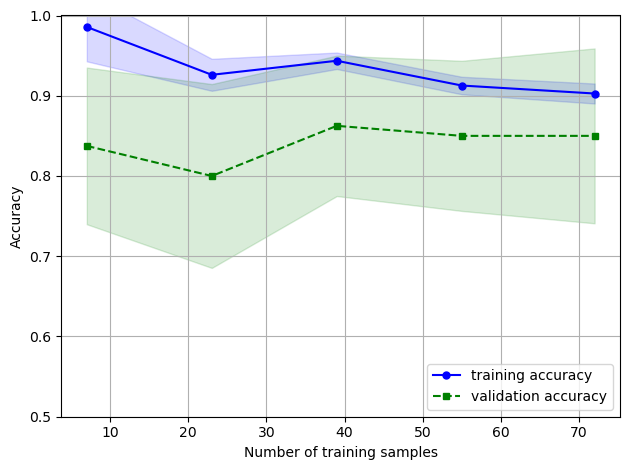

In [17]:
# Kood: https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch06/ch06.ipynb
# S.Raschka, Python Machine Learning

import matplotlib.pyplot as plt


%matplotlib inline



plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.5, 1.0])
plt.tight_layout()
# plt.savefig('./figures/learning_curve.png', dpi=300)
plt.show()

Me näeme, et väikestel andmetel on käärid treening- ja testandmete vahel suured (ca 0.99 täpsus treeningandmetel ja 0.85 testandmetel). Sellisel juhul tuleb loomulikult eelistada hinnangut testandmetel. Kõrge täpsus treeningandmetel on ilmselt tingitud ülesobitusest (*overfitting*): mudelisse on kodeeritud konkreetsete treeningeksemplaride oodatavad klassid, aga uute objektidega töötab mudel halvasti, kuna sel puudub üldistusjõud. Selline nähtus on kerge tekkima kui mudeli keerukus on võrreldav treeningandmete keerukusega. Me soovime, et mudel oleks lihtsam ja seega üldisem kui andmed, millel see treeniti. Suurandmetega võib treenida keerukamaid mudeleid.

<a id='validatsioonikõverad'></a>
##  Validatsioonikõverad (*validation curves*)


Validatsioonikõver näitab treening- ja testtäpsuse sõltuvust klassifikaatori teatud treeningparameetrist. See võimaldab hinnata selle parameetri mõju ja optimaalset väärtust.

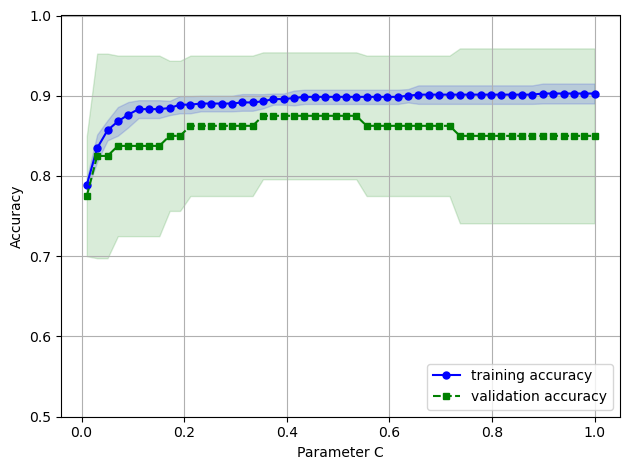

In [18]:
from sklearn.model_selection import validation_curve

#param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
param_range = np.linspace(0.01, 1, 50)
train_scores, test_scores = validation_curve(
                estimator=pipe_lr, 
                X=X_train, 
                y=y_train, 
                param_name='clf__C', #formaat: KonveieriKomponendiNimi__ParameetriNimi
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='validation accuracy')

plt.fill_between(param_range, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
#plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1.0])
plt.tight_layout()
# plt.savefig('./figures/validation_curve.png', dpi=300)
plt.show()

<a id='hüper'></a>
## Hüperparameetrite tuunimine

Ennustavatel mudelitel on tüüpiliselt hulk parameetreid, mille abil juhitakse treeningprotsessi, mida võib nimetada hüperparameetriteks. Need erinevad parameetritest, mida treenitakse (närvivõrgu kaalud jms) ja nende seadistusest võib sõltuda mudeli headus. Hüperparameetrite tuunimine tähendab mingi mõõdiku järgi (täpsus vms) optimaalsete parameetrite automaatset otsingut.

Scikit-learn pakub selleks klasse, nagu [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html).

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'clf__C': np.linspace(0.01, 1, 20),
               'clf__solver': ['lbfgs'],
               'clf__penalty': ['l2']}, #solver lbfgs ei toeta penaltit l1
              # liblinear toetab, selle jaoks on oma valikutega 'grid'
              {'clf__C': np.linspace(0.01, 1, 20),
               'clf__solver': ['liblinear'],
               'clf__penalty': ['l1', 'l2']}]

gs = GridSearchCV(estimator=pipe_lr, 
                  param_grid=param_grid, 
                  scoring='accuracy', 
                  cv=10,
                  n_jobs=-1)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.875
{'clf__C': 0.37473684210526315, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


In [20]:
pipe_lr_tuned = Pipeline([('sc1', StandardScaler()),
                    ('clf', LogisticRegression(C=0.06,
                                               solver='liblinear',
                                               penalty='l1', 
                                               random_state=1))])

# Olemasolevat Pipeline objekti saaks tulemuste abil lühemalt muuta ka nii:
# pipe_lr.set_params(**gs.best_params_)

<a id='Eksimismaatriks'></a>
## Eksimismaatriks (*confusion matrix*)

Eksimismaatriks on 2x2 maatriks: ennustatud klass võib olla positiivne või negatiivne, tegelik klass võib olla positiivne või negatiivne. Ideaalis langevad ennustatud ja tegelikud väärtused alati kokku, aga kui mitte, siis võib olla oluline, mis tüüpi vigadega on valdavalt tegemist: kas **valepositiivsete** või **valenegatiivsete** tulemustega. Erineval veal võivad olla erinevad kaalud (haiguse tuvastamata jätmine on tavaliselt tõsisem probleem kui ekslik positiivne diagnoos), klasside jaotus ei pruugi olla 50:50, mis muudab täpsuse vahel eksitavaks mõõduks (mudel, mis ennustab alati sagedaseimat tulemust näitab head täpsust) jne. 

 |           | Ennustatud P         | Ennustatud N         |
 |-----------|----------------------|----------------------|
 | Tegelik P | Õige positiivne (TP) | Vale negatiivne (FN) |
 | Tegelik N | Vale positiivne (FP) | Õige negatiivne (TN) |

 


Vaatame järgnevalt, kuidas klassid jaotuvad meie andmetes.

In [21]:
np.bincount(zoo_class)

array([65, 36], dtype=int64)

Näeme, et ca 2/3 loomadest pole veeloomad ja 1/3 on, seega klassid pole jaotunud ühtlaselt.

 Scikit-learn moodul metrics pakub eksimismaatriksi genereerimiseks funktsiooni [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix).

In [22]:
from sklearn.metrics import confusion_matrix

pipe_lr_tuned.fit(X_train, y_train)
y_pred = pipe_lr_tuned.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=[1,0])
print(confmat)

[[ 3  3]
 [ 0 15]]


Väärtuste $TP, TN, FP, FN$ on võimalik defineerida järgmised mõõdikud: 


Ennustustäpsus (ACC) ja ennustusviga (ERR):

$$ ACC = \frac{TP + TN}{FP + FN + TP + TN} = 1 - ERR $$

$$ ERR = \frac{FP + FN}{FP + FN + TP + TN} $$

Näitavad, milline osa ennustustest vastas või ei vastanud tegelikkusele.

Tundlikkus ehk õige-positiivsete määr (TPR), tuntud ka  kui täielikkus (Recall REC):

$$ TPR = REC = \frac{TP}{FN + TP}$$

Näitab, milline osa tegelikest positiivsetest ennustati positiivseteks.

Spetsiifilisus ehk õige-negatiivsete määr (TNR):

$$ TNR = \frac{TN}{FP + TN}$$

Näitab, milline osa tegelikest negatiivsetest ennustati negatiivseteks.

Positiivne ennustusvõime (PPV, Precision, PRE):

$$ PRE = \frac {TP} {TP+FP} $$

Näitab, milline osa ennustatud positiivsetest olid tegelikult positiivsed.

Negatiivne ennustusvõime (NPV):

$$ NPV = \frac {TN} {TN+FN} $$

Näitab, milline osa ennustatud negatiivsetest olid tegelikult negatiivsed.

Tihti kombineeritakse $PRE$ ja $REC$ nn $F1$ skooriks:

$$ F1 = 2 \frac{PRE \times REC} {PRE + REC} $$

Vastavad funktsioonid nende mõõdikute leidmiseks on saadaval moodulis [sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true=y_test, y_pred=y_pred))
print("Recall:", recall_score(y_true=y_test, y_pred=y_pred))
print("F1:", f1_score(y_true=y_test, y_pred=y_pred))

Precision: 1.0
Recall: 0.5
F1: 0.6666666666666666


<a id='roc'></a>
## ROC kõver


Kui meetod väljastab klassi asemel tõenäosushinnangu vahemikus 0..1, siis kerkib küsimus, milline lävi oleks sobilik klassikuuluvuse osas positiivse otsuse tegemiseks? 0.5 on intuitiivne lävi, aga ei pruugi olla parim, eriti kui valepositiivse ja valenegatiivse tulemuse "hind" pole võrdne. Suurendades läve vähendame valepositiivsete tulemuste arvu, aga samas ka õigete positiivsete tulemuste  arvu. ROC kõver visualiseerib seda olukorda, näidates x-teljel vale-positiivsete tulemuste ja y-teljel õigete positiivsete tulemuste protsenti. Läve enda väärtust telgedel otse näha ei ole, lävi on kõvera vastavas punktis see, mis annab tulemuseks punkti poolt määratud õige/vale - positiivsete tulemuste arvu.

Optimaalsed läved minimeerivad kaugust koordinaatide vasakust ülanurgast (õiged positiivsed: 100%, valepositiivsed 0%).

Klassifikaatori summaarse headuse mõõduna kasuatakse tihti ka kõvera aluse pindala (*area-under-curve*) mõõtu.


In [24]:
from sklearn.metrics import roc_auc_score
y_pp = pipe_lr_tuned.predict_proba(X_test)
print("Tõenäosused: ", y_pp)
print("ROC kõvera alune pindala:", roc_auc_score(y_true=y_test, y_score=y_pp[:,1]))

Tõenäosused:  [[0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.35821125 0.64178875]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.2718676  0.7281324 ]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.4696527  0.5303473 ]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]
 [0.56966704 0.43033296]]
ROC kõvera alune pindala: 0.75


C:\Users\Maive\AppData\Local\Temp\ipykernel_20928\1012657886.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, thresholds = roc_curve(y_train[test],
C:\Users\Maive\AppData\Local\Temp\ipykernel_20928\1012657886.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, thresholds = roc_curve(y_train[test],
C:\Users\Maive\AppData\Local\Temp\ipykernel_20928\1012657886.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


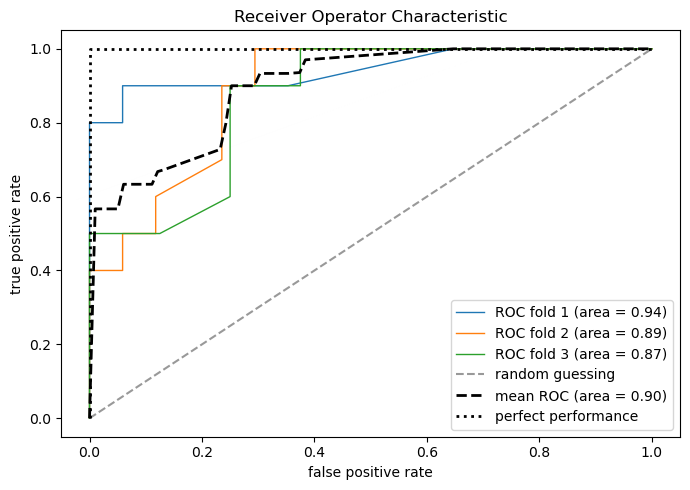

In [25]:
from sklearn.metrics import roc_curve, auc
from numpy import interp

pipe_lr = Pipeline([('scl', StandardScaler()),
                    ('pca', PCA(n_components=2)),
                    ('clf', LogisticRegression(penalty='l2',
                                               
                                               random_state=0, 
                                               C=0.35))])

#pipe_lr = pipe_lr_tuned

#X_train2 = X_train.iloc[:, [4, 14]]

X_train2 = X_train[:]

cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))

fig = plt.figure(figsize=(7, 5))

mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2.iloc[train],
                         y_train.iloc[train]).predict_proba(X_train2.iloc[test])

    fpr, tpr, thresholds = roc_curve(y_train[test],
                                     probas[:, 1],
                                     pos_label=1)
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,
             tpr,
             lw=1,
             label='ROC fold %d (area = %0.2f)'
                   % (i+1, roc_auc))

plt.plot([0, 1],
         [0, 1],
         linestyle='--',
         color=(0.6, 0.6, 0.6),
         label='random guessing')

mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, 'k--',
         label='mean ROC (area = %0.2f)' % mean_auc, lw=2)
plt.plot([0, 0, 1],
         [0, 1, 1],
         lw=2,
         linestyle=':',
         color='black',
         label='perfect performance')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('Receiver Operator Characteristic')
plt.legend(loc="lower right")

plt.tight_layout()
# plt.savefig('./figures/roc.png', dpi=300)
plt.show()

<a id='7_2'></a>
## Ülesanne 7.2

Jätkates tööd loomaaia andmetega:

* Joonistada õppimiskõverad ülesande 7.1 konveieritele. 

* Tuunida [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearchcv#sklearn.model_selection.GridSearchCV) või muu sarnase klassi abil kahe järgmise konveieri järgmised hüperparameetrid:
    * [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html): k,
[DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html): criterion, max_depth.
    * [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), 
[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html): n_components,
[Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html): eta0, max_iter, penalty. Siin tasub olla ettevaatlik valikutest tulenevate kombinatsioonide arvuga, muidu võib tööaeg kujuneda pikaks.

* Seadistada need kaks konveierit leitud optimaalsete hüperparameetritega ja leida neile eksimismaatriksid. Milline kahest mõõdikust - $REC, PRE$ - on väikseima väärtusega? Arvutada ja esitada selle väärtus (kas peast maatriksi põhjal või funktsiooniga). Arvutada ka $F1$ skoor ja võrrelda seda lihtsa ennustustäpsusega $ACC$



c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 7  9 12 13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\feature

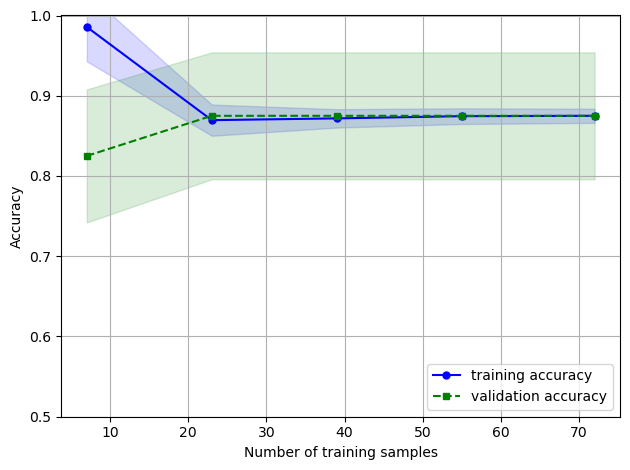

In [26]:
# Õppimiskõver näitab treening- ja testtäpsuse sõltuvust andmestiku suurusest. 
# See võimaldab hinnata kuivõrd paraneks täpsus andmemahtu suurendades.

# Õppimiskõver SelectKBest ja DecisionTreeClassifier konveierile
train_sizes1, train_scores1, test_scores1 =\
                learning_curve(estimator=pipeline1,
                               X=X_train1,
                               y=y_train1,
                               train_sizes=np.linspace(0.1, 1.0, 5),
                               scoring='accuracy',
                               cv=10,
                               n_jobs=1)
                
train_mean1 = np.mean(train_scores1, axis=1)
train_std1 = np.std(train_scores1, axis=1)
test_mean1 = np.mean(test_scores1, axis=1)
test_std1 = np.std(test_scores1, axis=1)

plt.plot(train_sizes1, train_mean1,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

plt.fill_between(train_sizes1,
                 train_mean1 + train_std1,
                 train_mean1 - train_std1,
                 alpha=0.15, color='blue')

plt.plot(train_sizes1, test_mean1,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

plt.fill_between(train_sizes1,
                 test_mean1 + test_std1,
                 test_mean1 - test_std1,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.5, 1.0])
plt.tight_layout()
plt.show()

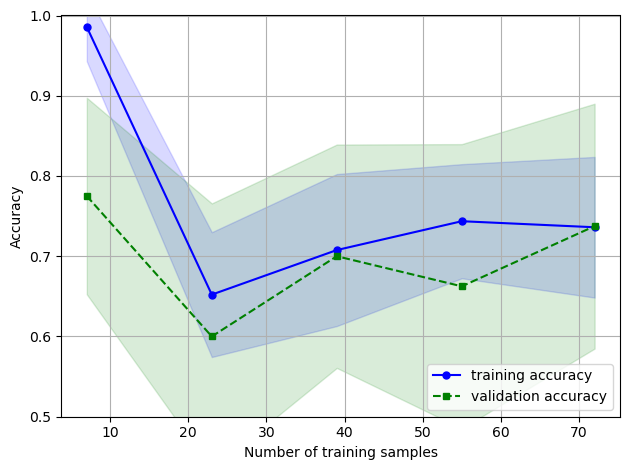

In [27]:
# Õppimiskõver StandardScaler, PCA(parameeter `n_components=2`),Perceptron konveierile
train_sizes2, train_scores2, test_scores2 =\
                learning_curve(estimator=pipeline2,
                               X=X_train2,
                               y=y_train2,
                               train_sizes=np.linspace(0.1, 1.0, 5),
                               scoring='accuracy',
                               cv=10,
                               n_jobs=1)
                
train_mean2 = np.mean(train_scores2, axis=1)
train_std2 = np.std(train_scores2, axis=1)
test_mean2 = np.mean(test_scores2, axis=1)
test_std2 = np.std(test_scores2, axis=1)

plt.plot(train_sizes2, train_mean2,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

plt.fill_between(train_sizes2,
                 train_mean2 + train_std2,
                 train_mean2 - train_std2,
                 alpha=0.15, color='blue')

plt.plot(train_sizes2, test_mean2,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

plt.fill_between(train_sizes2,
                 test_mean2 + test_std2,
                 test_mean2 - test_std2,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.5, 1.0])
plt.tight_layout()
plt.show()

In [28]:
# * Tuunida [GridSearchCV] või muu sarnase klassi abil kahe järgmise konveieri järgmised hüperparameetrid:
#     * [SelectKBest]: k,
# [DecisionTreeClassifier]: criterion, max_depth.
#     * [StandardScaler], 
# [PCA]: n_components,
# [Perceptron]: eta0, max_iter, penalty. Siin tasub olla ettevaatlik valikutest tulenevate kombinatsioonide arvuga, muidu võib tööaeg kujuneda pikaks.


In [29]:
# SelectKBest ja DecisionTreeClassifier konveieri hüperparameetrite tuunimine
# SelectKBest: k,
# DecisionTreeClassifier: criterion, max_depth.
param_grid1 = {'selectkbest__k': np.array(range(1, 13)),
               'decisiontreeclassifier__criterion': ["gini", "entropy", "log_loss"], 
               'decisiontreeclassifier__max_depth': np.array(range(1, 13))}
            

gs1 = GridSearchCV(estimator=pipeline1, 
                  param_grid=param_grid1, 
                  scoring='accuracy', 
                  cv=10,
                  n_jobs=-1)
gs1 = gs1.fit(X_train1, y_train1)
print(gs1.best_score_)
print(gs1.best_params_)


0.875
{'decisiontreeclassifier__criterion': 'gini', 'decisiontreeclassifier__max_depth': 2, 'selectkbest__k': 2}


In [30]:
# StandardScaler, PCA(parameeter `n_components=2`),Perceptron konveieri hüperparameetrite tuunimine
param_grid2 = {'pca__n_components': np.arange(1, 12), 
               'perceptron__eta0': np.linspace(0.1, 2, 5), 
               'perceptron__max_iter': np.linspace(100, 2000, 5),
               'perceptron__penalty': ['l2','l1','elasticnet', None]}
            

gs2 = GridSearchCV(estimator=pipeline2, 
                  param_grid=param_grid2, 
                  scoring='accuracy', 
                  cv=10,
                  n_jobs=-1)
gs2 = gs2.fit(X_train2, y_train2)
print(gs2.best_score_)
print(gs2.best_params_)

0.85
{'pca__n_components': 10, 'perceptron__eta0': 5.6, 'perceptron__max_iter': 100, 'perceptron__penalty': 'elasticnet'}


In [35]:
pipeline1

Pipeline(steps=[('selectkbest', SelectKBest(k=2)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=2))])

In [36]:
##Seadistada need kaks konveierit leitud optimaalsete hüperparameetritega ja leida neile eksimismaatriksid.
pipeline1.set_params(**gs1.best_params_)
pipeline1.fit(X_train1, y_train1)

pipeline2.set_params(**gs2.best_params_)
pipeline2.fit(X_train2, y_train2)

Pipeline(steps=[('sc1', StandardScaler()), ('pca', PCA(n_components=10)),
                ('perceptron',
                 Perceptron(eta0=5.6, max_iter=100, penalty='elasticnet'))])

In [37]:
## Leia eksimismaatriksid - esimeses tulbas õige positiivsete ja vale positiivsete arvud, teises tulbas vale negatiivsed ja õige negatiivsed
y_pred1 = pipeline1.predict(X_test1)
confmat1 = confusion_matrix(y_true=y_test1, y_pred=y_pred1)
print(confmat1)

y_pred2 = pipeline2.predict(X_test2)
confmat2 = confusion_matrix(y_true=y_test2, y_pred=y_pred2)
print(confmat1)

[[15  0]
 [ 3  3]]
[[15  0]
 [ 3  3]]


In [39]:
# Milline kahest mõõdikust - REC - recall (näitb milline osa tegelikest positiivsetest ennustati positiivseteks), 
# PRE - precision (näitab milline osa ennustatud positiivsetest olid tegelikult positiivsed) - on väikseima väärtusega? 
# Arvutada ja esitada selle väärtus.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Recall (REC) pipeline1:", recall_score(y_true=y_test1, y_pred=y_pred1))
print("Precision (PRE) pipeline 1:", precision_score(y_true=y_test1, y_pred=y_pred1))
# Pipeline 1-l on väiksem REC

print("Recall (REC) pipeline 2:", recall_score(y_true=y_test2, y_pred=y_pred2))
print("Precision (PRE) pipeline 2:", precision_score(y_true=y_test2, y_pred=y_pred2))
# Pipeline 2-l on väiksem PRE



Recall (REC) pipeline1: 0.5
Precision (PRE) pipeline 1: 1.0
Recall (REC) pipeline 2: 0.8333333333333334
Precision (PRE) pipeline 2: 0.625


In [40]:
# #Arvutada F1 skoor ja võrrelda seda lihtsa ennustustäpsusega ACC
# Tihti kombineeritakse PRE ja REC F1 skooriks: F1 = (2*PRE*REC)/(PRE+REC)
# F1 skoori on parem kasutada, kui tegu pole balanseeritud andmetega (st et andmestikus pos ja neg andmeid on eri proportsioon)
print("F1 pipeline 1:", f1_score(y_true=y_test1, y_pred=y_pred1))
print("F1 pipeline 2:", f1_score(y_true=y_test2, y_pred=y_pred2))

# ACC näitab milline osa ennustustest vastas tegelikkusele
print("Accuracy pipeline1:", accuracy_score(y_true=y_test1, y_pred=y_pred1))
print("Accuracy pipeline2:", accuracy_score(y_true=y_test2, y_pred=y_pred2))



F1 pipeline 1: 0.6666666666666666
F1 pipeline 2: 0.7142857142857143
Accuracy pipeline1: 0.8571428571428571
Accuracy pipeline2: 0.8095238095238095
